In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import shapiro

import matplotlib.pyplot as plt

# Cargar los datos
data = pd.read_csv('./movies_2026.csv', encoding='latin1')

In [2]:
# 1. Exploración rápida de los datos
print("Resumen del conjunto de datos:")
print("ejercicio 1 ")
print(data.info())
print("\nPrimeras filas del conjunto de datos:")
print(data.head())
print("\nEstadísticas descriptivas:")
print(data.describe(include='all'))

Resumen del conjunto de datos:
ejercicio 1 
<class 'pandas.DataFrame'>
RangeIndex: 19883 entries, 0 to 19882
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         19883 non-null  int64  
 1   budget                     19883 non-null  float64
 2   genres                     17918 non-null  str    
 3   homePage                   5607 non-null   str    
 4   productionCompany          14223 non-null  str    
 5   productionCompanyCountry   11473 non-null  str    
 6   productionCountry          16009 non-null  str    
 7   revenue                    19883 non-null  float64
 8   runtime                    19883 non-null  int64  
 9   video                      19397 non-null  object 
 10  director                   18907 non-null  str    
 11  actors                     17282 non-null  str    
 12  actorsPopularity           17275 non-null  str    
 13  actorsCharact

In [ ]:
# 2. Tipo de cada variable
print("\nTipo de cada variable:")
for column in data.columns:
    if data[column].dtype == 'object':
        print(f"{column}: Cualitativa nominal")
    elif data[column].dtype in ['int64', 'float64']:
        unique_values = data[column].nunique()
        if unique_values < 10:
            print(f"{column}: Cualitativa ordinal")
        elif data[column].dtype == 'int64':
            print(f"{column}: Cuantitativa discreta")
        else:
            print(f"{column}: Cuantitativa continua")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import shapiro

# 3. Distribución normal y tabla de frecuencias
print("\nPrueba de normalidad para variables cuantitativas:")
quantitative_columns = data.select_dtypes(include=['int64', 'float64']).columns

# Crear gráficos de distribución para variables cuantitativas
for column in quantitative_columns:
    stat, p_value = shapiro(data[column].dropna())
    distribution = "Normal" if p_value > 0.05 else "No Normal"
    print(f"{column}: {distribution} (p-value={p_value:.4f})")
    
    # Crear histograma
    plt.figure(figsize=(8, 5))
    plt.hist(data[column].dropna(), bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Distribución de {column} ({distribution})')
    plt.xlabel(column)
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

print("\nTablas de frecuencias para variables cualitativas:")
qualitative_columns = data.select_dtypes(include=['object']).columns

# Crear gráficos de barras para variables cualitativas
for column in qualitative_columns:
    frequency_table = data[column].value_counts()
    print(f"\nTabla de frecuencias para {column}:")
    print(frequency_table)
    
    # Crear gráfico de barras
    plt.figure(figsize=(8, 5))
    frequency_table.plot(kind='bar', color='lightcoral', edgecolor='black')
    plt.title(f'Tabla de frecuencias para {column}')
    plt.xlabel(column)
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

In [3]:
df = pd.read_csv("movies_2026.csv", encoding="latin1")
df["releaseDate"] = pd.to_datetime(df["releaseDate"], errors="coerce")
df["main_genre"] = df["genres"].str.split("|").str[0]


In [4]:
df_ingresos = df[df["revenue"] > 0]
df_presupuesto = df[df["budget"] > 0]
df_finanzas = df[(df["budget"] > 0) & (df["revenue"] > 0)]


In [5]:
top10_presupuesto = (
    df_presupuesto[["title", "budget"]]
    .sort_values(by="budget", ascending=False)
    .head(10)
)

display(top10_presupuesto)
tabla_frecuencia_41 = (
    top10_presupuesto["title"]
    .value_counts()
    .reset_index()
)

tabla_frecuencia_41.columns = ["Película", "Frecuencia"]
tabla_frecuencia_41



,title,budget
10606,Pirates of the Caribbean: On Stranger Tides,380000000.0
14600,Avengers: Age of Ultron,365000000.0
15842,Avengers: Endgame,356000000.0
5907,Avatar: Fire and Ash,350000000.0
15843,Avengers: Infinity War,300000000.0
10053,Pirates of the Caribbean: At World's End,300000000.0
14843,Justice League,300000000.0
10497,Superman Returns,270000000.0
17024,The Lion King,260000000.0
13681,Tangled,260000000.0


,Película,Frecuencia
0,Pirates of the Caribbean: On Stranger Tides,1
1,Avengers: Age of Ultron,1
2,Avengers: Endgame,1
3,Avatar: Fire and Ash,1
4,Avengers: Infinity War,1
5,Pirates of the Caribbean: At World's End,1
6,Justice League,1
7,Superman Returns,1
8,The Lion King,1
9,Tangled,1


In [6]:
import pandas as pd
top10_ingresos = (
    df[["title", "revenue"]]
    .sort_values(by="revenue", ascending=False)
    .head(10)
)

top10_ingresos

,title,revenue
13100,Avatar,2.847246e+09
15842,Avengers: Endgame,2.797801e+09
10197,Titanic,2.187464e+09
14837,Star Wars: The Force Awakens,2.068224e+09
15843,Avengers: Infinity War,2.046240e+09
8481,Zootopia 2,1.744338e+09
14804,Jurassic World,1.671713e+09
17024,The Lion King,1.667635e+09
18937,Spider-Man: No Way Home,1.631853e+09
13287,The Avengers,1.518816e+09


In [7]:
pelicula_mas_votos = df.loc[
    df["voteCount"].idxmax(),
    ["title", "voteCount"]
]

pelicula_mas_votos

title        Inception
voteCount        30788
Name: 13401, dtype: object

In [8]:
peor_pelicula = (
    df[df["voteCount"] > 0]
    .sort_values(by="voteAvg")
    .head(1)[["title", "voteAvg"]]
)

peor_pelicula

,title,voteAvg
5303,Jingle Bell Wedding,0.0


In [9]:
df["releaseDate"] = pd.to_datetime(df["releaseDate"], errors="coerce")
df["main_genre"] = df["genres"].str.split("|").str[0]
top20_recientes = (
    df.sort_values(by="releaseDate", ascending=False)
    .head(20)[["title", "releaseDate", "main_genre"]]
)

top20_recientes

,title,releaseDate,main_genre
488,A Fading Man,2026-05-07,Drama
7895,Elon Musk Unveiled â The Tesla Experiment,2026-03-12,Documentary
4054,Skunk,2026-02-25,NaN
4760,Anastasia,2026-02-25,NaN
6897,Nikki hako no koi,2026-02-06,NaN
0,Immersed,2026-02-01,Drama
44,You Just Watch & See,2026-02-01,NaN
49,Waves Turn,2026-02-01,Documentary
48,Three Ways of Returning,2026-02-01,NaN
47,AGOS-TONO,2026-02-01,Music


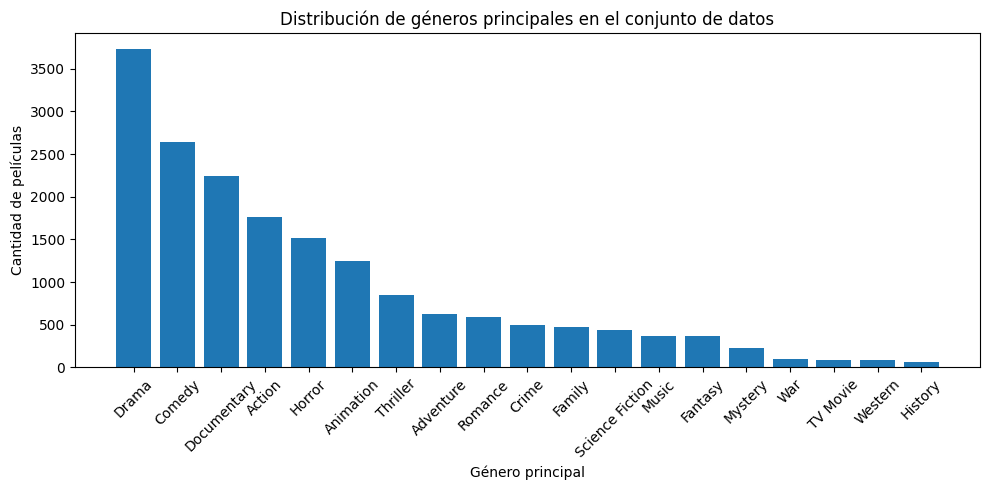

In [14]:
frecuencia_generos = (
    df["main_genre"]
    .value_counts()
    .reset_index()
)

frecuencia_generos.columns = ["Género principal", "Cantidad de películas"]

frecuencia_generos

frecuencia_generos.head(1)

plt.figure(figsize=(10, 5))
plt.bar(
    frecuencia_generos["Género principal"],
    frecuencia_generos["Cantidad de películas"]
)

plt.xlabel("Género principal")
plt.ylabel("Cantidad de películas")
plt.title("Distribución de géneros principales en el conjunto de datos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [11]:
ingresos_por_genero = (
    df_ingresos
    .groupby("main_genre")["revenue"]
    .mean()
    .reset_index()
    .sort_values(by="revenue", ascending=False)
)

ingresos_por_genero.columns = ["Género principal", "Ingresos promedio"]

display(ingresos_por_genero)


,Género principal,Ingresos promedio
1,Adventure,2.194257e+08
2,Animation,1.693564e+08
14,Science Fiction,1.689934e+08
7,Family,1.640919e+08
0,Action,1.594615e+08
8,Fantasy,1.492534e+08
16,War,1.051353e+08
9,History,8.265835e+07
3,Comedy,7.939863e+07
11,Music,7.595241e+07
